In [2]:
import pandas as pd
import numpy as np


In [3]:
data = pd.read_csv('titanic_data/train.csv')

In [4]:
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [11]:
nan_summary = data.isna().sum()
nan_columns = nan_summary[nan_summary > 0]
nan_columns

In [14]:
data = data.dropna(subset=['Embarked'])

In [15]:
nan_summary = data.isna().sum()

In [16]:
nan_columns = nan_summary[nan_summary > 0]

In [17]:
print(nan_columns)

Age      177
Cabin    687
dtype: int64


In [19]:
data[data['Age'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [22]:
data['Age'] = data.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))  # Filling NaN in Age column by values from similar group

C:\Users\G526511\AppData\Local\Temp\ipykernel_21892\970659921.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Age'] = data.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))


In [23]:
data[data['Age'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [27]:
data['Cabin'] = data['Cabin'].fillna(-1)  # Filling Nan value in Cabin as -1 to indicate unknown

C:\Users\G526511\AppData\Local\Temp\ipykernel_21892\506730915.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cabin'] = data['Cabin'].fillna(-1)


In [29]:
nan_summary = data.isna().sum()
nan_columns = nan_summary[nan_summary > 0]
nan_columns

Series([], dtype: int64)

In [102]:
X = data.drop('Name', axis=1)

In [103]:
X

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,-1,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,-1,S
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,male,35.0,0,0,373450,8.0500,-1,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,211536,13.0000,-1,S
887,888,1,1,female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,female,21.5,1,2,W./C. 6607,23.4500,-1,S
889,890,1,1,male,26.0,0,0,111369,30.0000,C148,C


In [104]:
X = X.drop('Survived', axis=1)

In [105]:
y = data['Survived']

In [106]:
y.head()


0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [107]:
X.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,male,22.0,1,0,A/5 21171,7.2500,-1,S
1,2,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,female,26.0,0,0,STON/O2. 3101282,7.9250,-1,S
3,4,1,female,35.0,1,0,113803,53.1000,C123,S
4,5,3,male,35.0,0,0,373450,8.0500,-1,S


In [108]:
X = X.drop('Ticket', axis=1)

In [109]:
X.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,1,3,male,22.0,1,0,7.2500,-1,S
1,2,1,female,38.0,1,0,71.2833,C85,C
2,3,3,female,26.0,0,0,7.9250,-1,S
3,4,1,female,35.0,1,0,53.1000,C123,S
4,5,3,male,35.0,0,0,8.0500,-1,S


In [110]:
X

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,1,3,male,22.0,1,0,7.2500,-1,S
1,2,1,female,38.0,1,0,71.2833,C85,C
2,3,3,female,26.0,0,0,7.9250,-1,S
3,4,1,female,35.0,1,0,53.1000,C123,S
4,5,3,male,35.0,0,0,8.0500,-1,S
...,...,...,...,...,...,...,...,...,...
886,887,2,male,27.0,0,0,13.0000,-1,S
887,888,1,female,19.0,0,0,30.0000,B42,S
888,889,3,female,21.5,1,2,23.4500,-1,S
889,890,1,male,26.0,0,0,30.0000,C148,C


In [111]:
X['Sex'] = X['Sex'].map({'male':0, 'female':1})

In [112]:
X

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,1,3,0,22.0,1,0,7.2500,-1,S
1,2,1,1,38.0,1,0,71.2833,C85,C
2,3,3,1,26.0,0,0,7.9250,-1,S
3,4,1,1,35.0,1,0,53.1000,C123,S
4,5,3,0,35.0,0,0,8.0500,-1,S
...,...,...,...,...,...,...,...,...,...
886,887,2,0,27.0,0,0,13.0000,-1,S
887,888,1,1,19.0,0,0,30.0000,B42,S
888,889,3,1,21.5,1,2,23.4500,-1,S
889,890,1,0,26.0,0,0,30.0000,C148,C


In [113]:
X = pd.get_dummies(X, columns=['Embarked'], drop_first=True)

In [114]:
X = X.drop("PassengerId", axis=1)

In [115]:

# Extract the first letter of the cabin (deck)
X['CabinDeck'] = X['Cabin'].str[0]

# Fill NaNs with a placeholder (e.g., 'U' for Unknown)
X['CabinDeck'] = X['CabinDeck'].fillna('U')
# One-hot encode
X = pd.get_dummies(X, columns=['CabinDeck'], drop_first=True)
X=X.drop('Cabin',axis=1)


In [116]:

X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_U
0,3,0,22.0,1,0,7.2500,False,True,False,False,False,False,False,False,False,True
1,1,1,38.0,1,0,71.2833,False,False,False,True,False,False,False,False,False,False
2,3,1,26.0,0,0,7.9250,False,True,False,False,False,False,False,False,False,True
3,1,1,35.0,1,0,53.1000,False,True,False,True,False,False,False,False,False,False
4,3,0,35.0,0,0,8.0500,False,True,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,0,27.0,0,0,13.0000,False,True,False,False,False,False,False,False,False,True
887,1,1,19.0,0,0,30.0000,False,True,True,False,False,False,False,False,False,False
888,3,1,21.5,1,2,23.4500,False,True,False,False,False,False,False,False,False,True
889,1,0,26.0,0,0,30.0000,False,False,False,True,False,False,False,False,False,False


In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [96]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [97]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7752808988764045
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       109
           1       0.69      0.75      0.72        69

    accuracy                           0.78       178
   macro avg       0.76      0.77      0.77       178
weighted avg       0.78      0.78      0.78       178



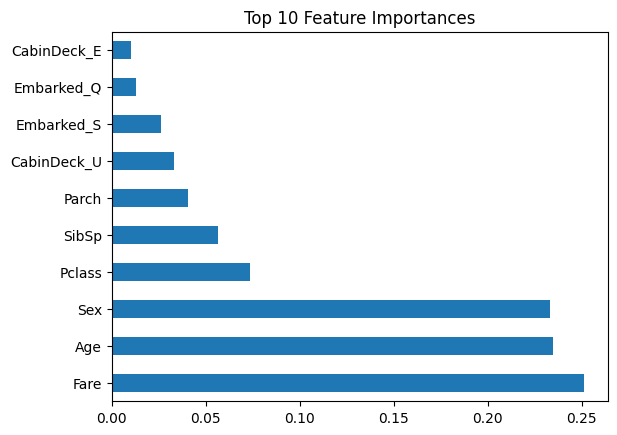

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.show()

In [120]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 889, dtype: int64

In [121]:
X_nn = X.values
y_nn = y.values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_nn, y_nn, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)


In [122]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [129]:
X_train

array([[-1.58410418,  1.40530972, -0.53538629, ..., -0.03752933,
        -0.03752933,  0.53669682],
       [ 0.8122747 ,  1.40530972, -0.57258668, ..., -0.03752933,
        -0.03752933,  0.53669682],
       [ 0.8122747 , -0.71158691,  0.20862144, ..., -0.03752933,
        -0.03752933,  0.53669682],
       ...,
       [-1.58410418,  1.40530972,  1.39903383, ..., -0.03752933,
        -0.03752933, -1.86324934],
       [ 0.8122747 ,  1.40530972, -0.60978707, ..., -0.03752933,
        -0.03752933,  0.53669682],
       [ 0.8122747 , -0.71158691,  0.28302222, ..., -0.03752933,
        -0.03752933,  0.53669682]])

In [130]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)


In [131]:
class TitanicNet(nn.Module):
    def __init__(self):
        super(TitanicNet, self).__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

model = TitanicNet()


In [132]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
for epoch in range(epochs):
    model.train()
    output = model(X_train_tensor)
    loss = criterion(output, y_train_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [10/100], Loss: 0.6494
Epoch [20/100], Loss: 0.6271
Epoch [30/100], Loss: 0.6042
Epoch [40/100], Loss: 0.5791
Epoch [50/100], Loss: 0.5513
Epoch [60/100], Loss: 0.5219
Epoch [70/100], Loss: 0.4916
Epoch [80/100], Loss: 0.4630
Epoch [90/100], Loss: 0.4383
Epoch [100/100], Loss: 0.4189


In [133]:
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    predicted_classes = (predictions >= 0.5).float()
    accuracy = (predicted_classes == y_test_tensor).float().mean()
    print(f"Test Accuracy: {accuracy.item():.4f}")


Test Accuracy: 0.8146
